# EXP-2026-003 / Q4-Q — transportability replication (quest49)

**상태: MEASURED — 2026-08-08 Colab L4 실행본.** 이 notebook에 PREP_DATA gate 통과, Q4-P 파생 분석(ANALYZE), full run(FULL)의 출력이 실행 당시 그대로 보존되어 있다(재실행 금지).

**판정(사전 등록 decision matrix, `result.json` 그대로): mechanism fail + utility fail → residual CNN 경로 중단.**

- run: `runs/20260808T1842_EXP-2026-003_q4q_transportability_replication` — code SHA `579fed7e72d1f4518a28fb2698249da1094cef3a`, data SHA `b1c16106…`(mamba_data.npz), DS1-fit 16 / dev 6 / DS2 22(1회 평가), endpoint 16 records, L4 237.7s
- 기전 DiD `(C−D)_S2−(C−D)_S0` = **−0.000441 [−0.001360, +0.000115]**, seed 1/5 양수 — SVDB에서 관측된 Q4-P B3 기전이 MIT로 **transport되지 않음**(부호 반전, 효과 ~1e-4로 사실상 0)
- utility `C−A`(S2) −0.000533 [−0.001498, +0.000029] → gate fail (p10 비열화만 통과)
- 정성 패턴만 재현: S2에서 best epoch 후행 이동(C: S0 [−1,0,−1,0,0] → S2 [2,2,1,2,1]) — metric 이득으로 이어지지 않음
- PREP_DATA: cross-check pass(44 matched, 4 paced leftovers, S 불일치 0 beat; record 208·213 beat 결손 warning), INCART 75→32 map 검증 통과, adapter gate는 설계대로 False(INCART full run 금지 — MIT fail로 진행하지 않음)
- ANALYZE(사후): Q4-P DiD +0.003434 [−0.000815, +0.008587] — B3 판정 불변, CI 0 포함
- 프로토콜 주석: 이 세션에서 FULL이 완결된 PREP_DATA 감사 기록보다 먼저 실행되었다(감사는 몇 분 뒤 같은 세션에서 통과; DS2 정보는 설계에 피드백되지 않음). 상세는 spec §11.

---

이하 설계 본문(사전 등록 — 수정 없음). 아래 셀들의 `NOT RUN`/skip 문구는 mode 분기 출력이며 이 실행본의 결과 상태와 무관하다.

- spec: `experiments/specs/EXP-2026-003-q4q-transportability-replication.md`
- 데이터 자산: `mamba_data.npz` `1p3HvC_bnbiQlEanFOVIvVdejy60W0tho` · `ecg_multi.npz` `1aSj_1jvS_W2iruVnORIG6DTVuHobzNzq` · INCART `.hea` folder `1rNgzVlVYuiBDBfSjhHXm-Ksbw54nKfgM` · Q4-P run `1qS8JxwlARByoZrJLMb6wxSIktQypiRTF`
- 실행 순서(재현 시): 셀 1 MODE 선택 → 셀 2(repo+tests) → 셀 3(경로) → PREP_DATA 셀 4 → ANALYZE 셀 5 → FULL 셀 6 → 셀 7(표·그림)

In [1]:
# ── cell 1: mode config — 정확히 하나만 활성 ────────────────────────────
MODE = "FULL"   # "DESIGN" | "SMOKE" | "PREP_DATA" | "FULL" | "ANALYZE"

VALID_MODES = ("DESIGN", "SMOKE", "PREP_DATA", "FULL", "ANALYZE")
assert MODE in VALID_MODES, f"MODE must be exactly one of {VALID_MODES}"
assert sum(MODE == m for m in VALID_MODES) == 1
print(f"MODE = {MODE}")
if MODE == "DESIGN":
    print("DESIGN mode: nothing is executed. FULL RESULT NOT RUN.")

MODE = FULL


In [2]:
# ── cell 2 (final v2): 실패 원인이 보이는 버전 ──
import os, subprocess, sys
os.chdir("/content")
REPO = "/content/my-github-test"
URL = "https://github.com/ehdbddl06001-ui/my-github-test.git"
RUN_TESTS = True

ok = os.path.isdir(os.path.join(REPO, ".git"))
if ok:
    p = subprocess.run(["git", "-C", REPO, "pull", "--ff-only"],
                       capture_output=True, text=True)
    ok = (p.returncode == 0)
if not ok:
    subprocess.run(["rm", "-rf", REPO], check=False)
    r = subprocess.run(["git", "clone", URL, REPO],
                       capture_output=True, text=True)
    if r.returncode:
        print(r.stderr); raise SystemExit("git clone failed")
os.chdir(REPO)

for name in ("q4q_transportability_replication",
             "q4p_best_epoch_zero_diagnostic",
             "q4o_leakage_free_residual"):
    sys.modules.pop(name, None)
sys.path = [p for p in sys.path if "mit-bih" not in p]
sys.path.insert(0, os.path.join(REPO, "mit-bih"))
import q4o_leakage_free_residual as Q4O
import q4p_best_epoch_zero_diagnostic as QP
import q4q_transportability_replication as QQ

NEED_Q4Q = 6
assert QQ.MODULE_VERSION >= NEED_Q4Q, "stale module - Restart runtime"
if RUN_TESTS:
    for suite in ("q4o_leakage_free_residual",
                  "q4p_best_epoch_zero_diagnostic",
                  "q4q_transportability_replication"):
        rr = subprocess.run([sys.executable, f"mit-bih/test_{suite}.py"],
                            capture_output=True, text=True)
        if rr.returncode != 0:
            print("\n".join((rr.stdout + "\n" + rr.stderr).splitlines()[-30:]))
            raise SystemExit(f"test suite failed: {suite} (returncode "
                             f"{rr.returncode}; -9 = 메모리 부족 → 런타임 재시작)")
print("module ok:", QQ.self_check()["module_build"])

module ok: 2026-08-08 q4q.6 — audit persists before the INCART step; cross-check identifies records by 5-class fingerprint assignment (beat counts drift several percent on noisy records under mamba's stricter prep); S strictly gated, all else reported; no full run has been executed


In [3]:
# ── cell 3: Drive mount + 경로 (DESIGN이면 skip) ─────────────────────────
if MODE == "DESIGN":
    print("skip - DESIGN mode. RESULT NOT RUN.")
else:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE = "/content/drive/MyDrive"
    DATA_MAMBA = f"{DRIVE}/mitbih/mamba_data.npz"
    DATA_MULTI = f"{DRIVE}/mitbih/ecg_multi.npz"
    INCART_HEA = f"{DRIVE}/mitbih/raw_ann/incartdb"
    Q4P_RUN = (f"{DRIVE}/MedKOS/ecg-model/runs/"
               "20260808T1310_EXP-2026-002_q4p_best_epoch_zero_diagnostic")
    import time as _t
    TS = _t.strftime("%Y%m%dT%H%M")
    OUT_RUN = (f"{DRIVE}/MedKOS/ecg-model/runs/"
               f"{TS}_EXP-2026-003_q4q_transportability_replication")
    OUT_PREP = f"{DRIVE}/MedKOS/ecg-model/runs/{TS}_EXP-2026-003_prep_data"
    OUT_DERIVED = (f"{DRIVE}/MedKOS/ecg-model/runs/"
                   f"{TS}_EXP-2026-002_q4p_derived_analysis_v1")
    for p, need in ((DATA_MAMBA, MODE in ("PREP_DATA", "FULL")),
                    (Q4P_RUN, MODE == "ANALYZE")):
        if need and not os.path.exists(p):
            raise SystemExit(f"missing input: {p} - fix the path, do not guess")
    print("paths ready; outputs are NEW versioned dirs (no overwrite)")

Mounted at /content/drive
paths ready; outputs are NEW versioned dirs (no overwrite)


In [7]:
# ── cell 4: PREP_DATA — data audit gate (FULL 전 필수) ───────────────────
if MODE != "PREP_DATA":
    print(f"skip - MODE={MODE}. Data audit NOT RUN in this session.")
else:
    QQ.main(["--mode", "PREP_DATA", "--data", DATA_MAMBA,
             "--multi", DATA_MULTI, "--incart-hea", INCART_HEA,
             "--out", OUT_PREP])
    import json
    audit = json.load(open(f"{OUT_PREP}/data_audit.json"))
    cc = audit["cross_check"]
    print("cross_check pass:", cc.get("pass"))
    print("explanation:", cc.get("explanation", cc.get("fail_reasons")))
    print("S agreement:", cc.get("s_agreement"))
    for w in cc.get("warnings", []):
        print("warning:", w)
    print("incart_map:", audit.get("incart_map", "NOT RUN"))
    print("adapter gate:", audit["incart_adapter_audit"]["gate_pass"],
          "(INCART full run은 gate_pass=True 전 금지)")

[   16.8s] MIT cohort: 99871 beats, 44 records, S=2781 (2.78%)
[   24.3s] cross-check pass: 44 matched, 4 paced leftovers, 2 beat-count warning(s)
[   27.4s] PREP_DATA audit written to /content/drive/MyDrive/MedKOS/ecg-model/runs/20260808T1838_EXP-2026-003_prep_data
[   27.4s]   100 -> multi   0  n  2271/ 2271  cls diff [0, 0, 0, 0, 0]
[   27.4s]   101 -> multi   1  n  1862/ 1864  cls diff [0, 0, 0, 0, 2]
[   27.4s]   103 -> multi   3  n  2083/ 2083  cls diff [0, 0, 0, 0, 0]
[   27.4s]   105 -> multi   5  n  2567/ 2572  cls diff [0, 0, 0, 0, 5]
[   27.4s]   106 -> multi   6  n  2027/ 2027  cls diff [0, 0, 0, 0, 0]
[   27.4s]   108 -> multi   8  n  1760/ 1762  cls diff [0, 0, 0, 2, 0]
[   27.4s]   109 -> multi   9  n  2528/ 2531  cls diff [1, 0, 0, 2, 0]
[   27.4s]   111 -> multi  10  n  2124/ 2124  cls diff [0, 0, 0, 0, 0]
[   27.4s]   112 -> multi  11  n  2537/ 2538  cls diff [1, 0, 0, 0, 0]
[   27.4s]   113 -> multi  12  n  1794/ 1794  cls diff [0, 0, 0, 0, 0]
[   27.4s]   114 -> mul

[    7.7s] derived analysis written to /content/drive/MyDrive/MedKOS/ecg-model/runs/20260808T1838_EXP-2026-002_q4p_derived_analysis_v1 (source bundle unchanged)
DiD (C-D) S2-S0: +0.003434 [-0.000815, +0.008587]
POST-HOC only - Q4-P의 사전 등록 판정(B3)은 바뀌지 않는다


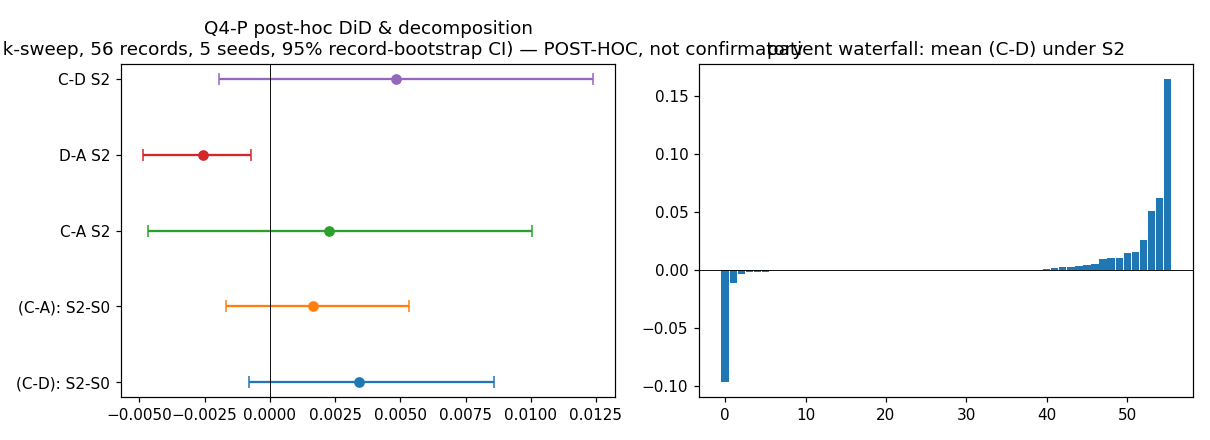

In [9]:
# ── cell 5: ANALYZE — Q4-P 무재학습 파생 분석 (사후 기전 분석) ───────────
if MODE != "ANALYZE":
    print(f"skip - MODE={MODE}. Q4-P derived analysis NOT RUN in this session.")
else:
    derived = QQ.q4p_derived_analysis(Q4P_RUN, OUT_DERIVED)
    rb = derived["did_cd_s2_minus_s0"]["record_bootstrap"]
    print(f"DiD (C-D) S2-S0: {rb['mean']:+.6f} "
          f"[{rb['ci_low']:+.6f}, {rb['ci_high']:+.6f}]")
    print("POST-HOC only - Q4-P의 사전 등록 판정(B3)은 바뀌지 않는다")
    from IPython.display import Image, display
    display(Image(f"{OUT_DERIVED}/derived_forest_waterfall.png"))

In [4]:
# ── cell 6: FULL — MIT DS1->DS2 replication run (T4) ────────────────────
if MODE != "FULL":
    print(f"skip - MODE={MODE}. FULL RESULT NOT RUN.")
else:
    prep_ok = input("PREP_DATA gate를 통과했는가? (yes/no): ").strip()
    assert prep_ok == "yes", "PREP_DATA gate 통과 전 FULL 금지"
    QQ.main(["--mode", "FULL", "--data", DATA_MAMBA, "--out", OUT_RUN])
    print("bundle:", OUT_RUN)

PREP_DATA gate를 통과했는가? (yes/no): yes
[    6.8s] MIT cohort: 99871 beats, 44 records, S=2781 (2.78%)
[   12.0s] EXP-2026-003/Q4-Q — device cuda, 5 seeds, 24 epochs, smoke=False; fit 16p / dev 6p / DS2 22p
[   17.9s] offsets: 5-group cross-fit on 16 fit patients; dev/DS2 scored by the full DS1-fit model
[   31.4s]   morph_plus_raw_residual/S0_original/seed 20260806: selected epoch -1
[   42.8s]   morph_plus_raw_residual/S2_alpha_low/seed 20260806: selected epoch 2
[   54.2s]   morph_plus_raw_residual/S0_original/seed 20260807: selected epoch 0
[   65.6s]   morph_plus_raw_residual/S2_alpha_low/seed 20260807: selected epoch 2
[   77.0s]   morph_plus_raw_residual/S0_original/seed 20260808: selected epoch -1
[   88.4s]   morph_plus_raw_residual/S2_alpha_low/seed 20260808: selected epoch 1
[   99.7s]   morph_plus_raw_residual/S0_original/seed 20260809: selected epoch 0
[  111.0s]   morph_plus_raw_residual/S2_alpha_low/seed 20260809: selected epoch 2
[  122.4s]   morph_plus_raw_residual/S0_ori

status: MEASURED | smoke: False
mechanism pass: False underpowered: False
waveform confirmatory: False
utility pass: False
action: mechanism and utility both fail -> stop the residual CNN path


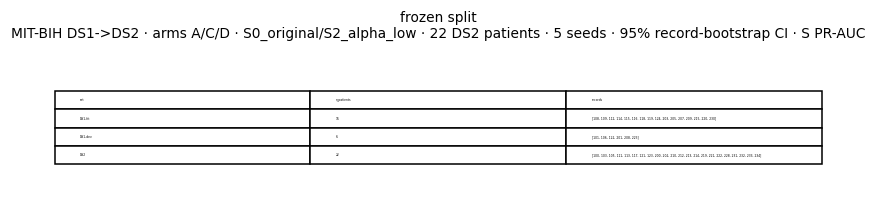

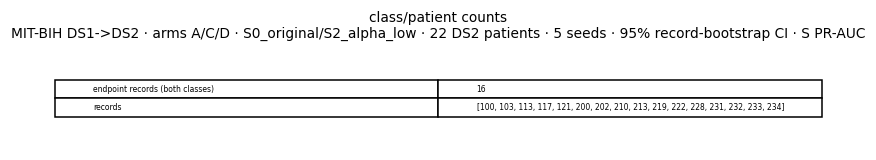

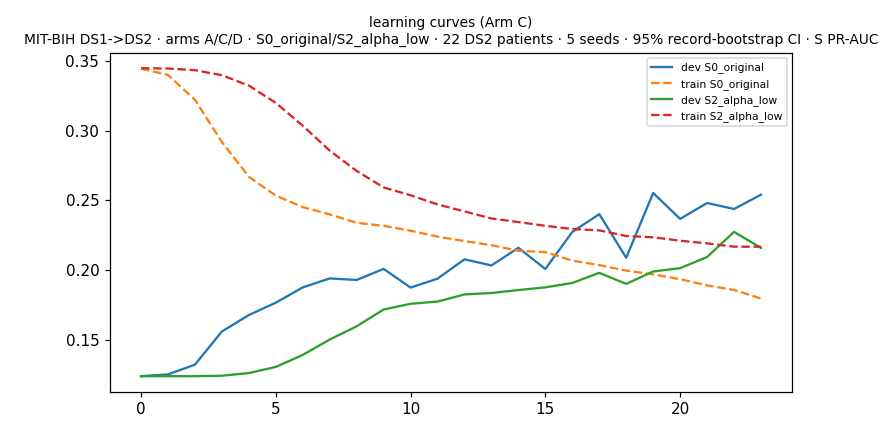

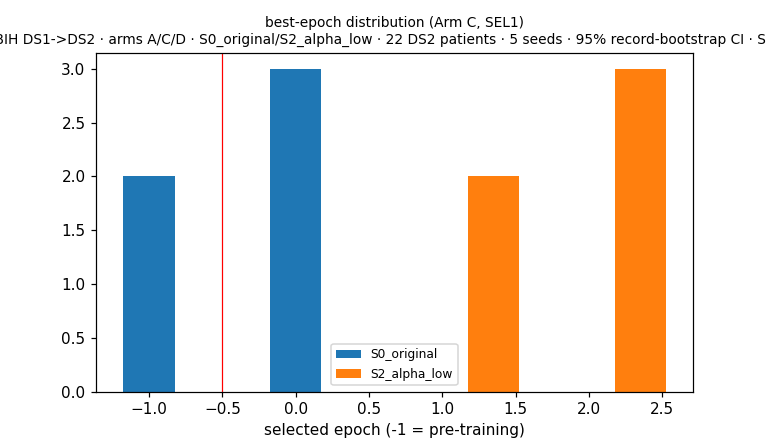

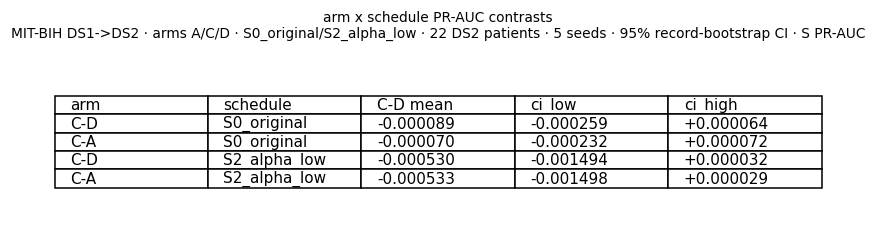

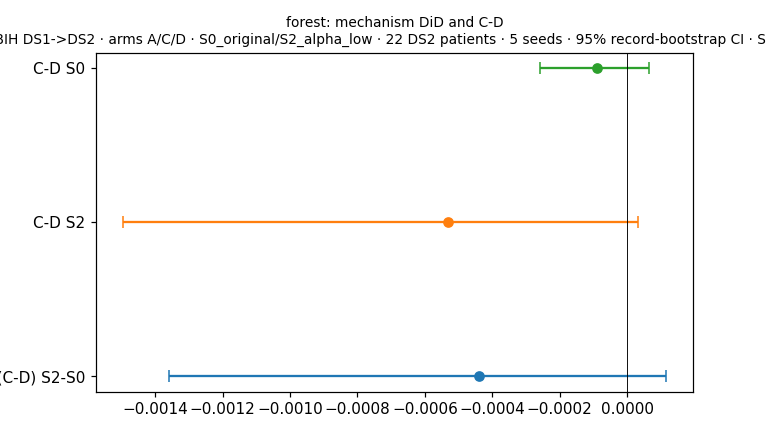

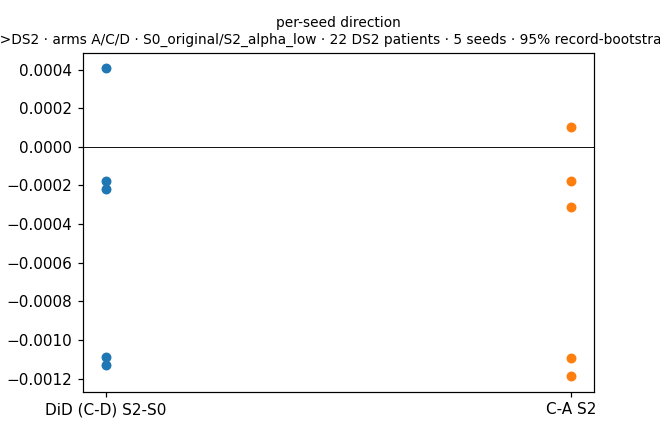

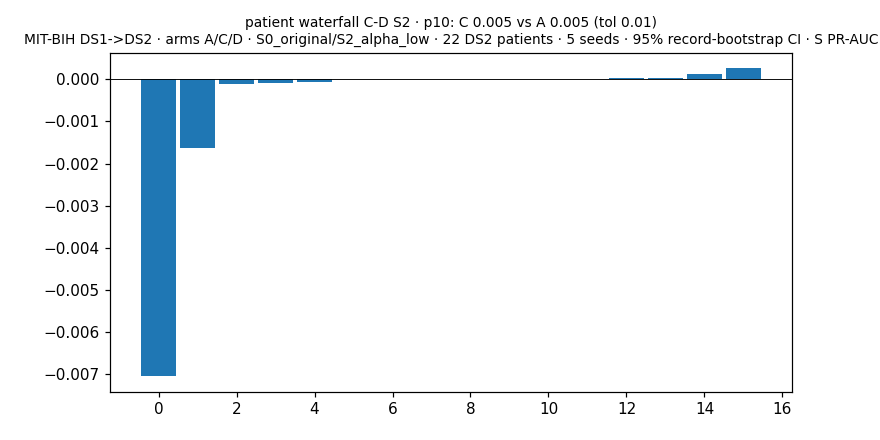

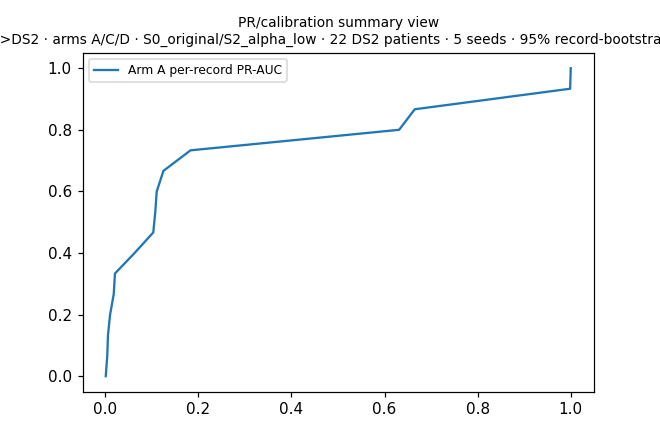

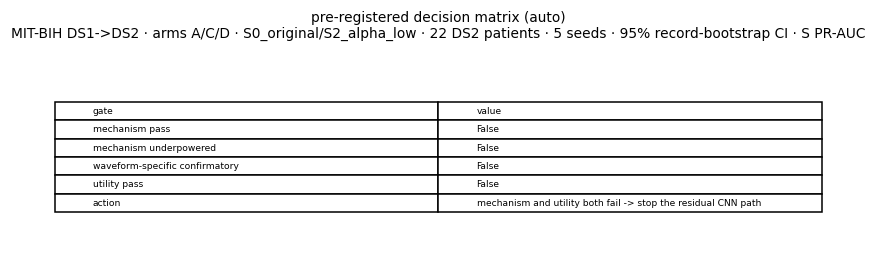

In [5]:
# ── cell 7: 결과 표시 (bundle 없으면 RESULT NOT RUN) ─────────────────────
import glob, json
run_dir = globals().get("OUT_RUN")
if not run_dir or not os.path.exists(f"{run_dir}/result.json"):
    print("RESULT NOT RUN - no measured bundle in this session.")
else:
    res = json.load(open(f"{run_dir}/result.json"))
    print("status:", res["status"], "| smoke:", res["smoke"])
    dm = res["decision_matrix"]
    print("mechanism pass:", dm["mechanism"]["pass"],
          "underpowered:", dm["mechanism"]["underpowered"])
    print("waveform confirmatory:", dm["waveform_specific"]["confirmatory"])
    print("utility pass:", dm["utility"]["pass"])
    print("action:", dm["action"])
    from IPython.display import Image, display
    for f in QQ.FIGURES:
        p = f"{run_dir}/figures/{f}"
        if os.path.exists(p):
            display(Image(p))

## 해석 경계 (사전 등록 요약)

- MIT-BIH는 과거 개발에 노출된 cohort — 이 실험은 **transportability replication**이지 untouched external confirmation이 아니다.
- DS2 결과를 보고 hyperparameter·preprocessing·selector를 바꾸지 않는다.
- 평균이 양수여도 CI가 0을 포함하면 **underpowered**로 기록한다. seed 추가는 patient 수 부족의 대체물이 아니다.
- INCART stage는 75→32 patient map과 adapter gate 통과 후에만, 동결 설계로 진행한다.